In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
SEED = 69
import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
print('Seed set')

I0000 00:00:1787454100.104242    6954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787454101.885276    6954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Seed set


In [2]:
!pip install kagglehub -q


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import applications, callbacks, layers, models, optimizers, regularizers, utils
warnings.filterwarnings('ignore')
print('Libraries ready')

Libraries ready


In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.13.0+cu132
CUDA available: True
CUDA version: 13.2
GPU: Tesla T4


In [5]:
import kagglehub
download_path = kagglehub.dataset_download('msambare/fer2013')

def find_split_root(base_path):
    base = Path(base_path)
    for root, dirs, files in os.walk(base):
        if 'train' in dirs and 'test' in dirs:
            return Path(root)
    return base

dataset_dir = find_split_root(download_path)
train_dir   = str(dataset_dir / 'train')
test_dir    = str(dataset_dir / 'test')
print('Train:', train_dir)
print('Test: ', test_dir)

Train: /home/ubuntu/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train
Test:  /home/ubuntu/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test


In [6]:
emotion_classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d)) and not d.startswith('.')
])
NUM_CLASSES = len(emotion_classes)

class_counts_train, class_counts_test = {}, {}
for cls in emotion_classes:
    class_counts_train[cls] = len(os.listdir(os.path.join(train_dir, cls)))
    class_counts_test[cls]  = len(os.listdir(os.path.join(test_dir,  cls)))
    print(f'  {cls:12s} -> train: {class_counts_train[cls]:5d} | test: {class_counts_test[cls]:5d}')
print(f'Total train: {sum(class_counts_train.values())} | Total test: {sum(class_counts_test.values())}')

  angry        -> train:  3995 | test:   958
  disgust      -> train:   436 | test:   111
  fear         -> train:  4097 | test:  1024
  happy        -> train:  7215 | test:  1774
  neutral      -> train:  4965 | test:  1233
  sad          -> train:  4830 | test:  1247
  surprise     -> train:  3171 | test:   831
Total train: 28709 | Total test: 7178


In [7]:
corrupted = []
for split_dir in [train_dir, test_dir]:
    for cls in emotion_classes:
        cls_path = os.path.join(split_dir, cls)
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                p = os.path.join(cls_path, f)
                try: Image.open(p).verify()
                except: corrupted.append(p)
for p in corrupted:
    try: os.remove(p)
    except: pass
print(f'Removed {len(corrupted)} corrupted' if corrupted else 'No corrupted images')

Removed 1 corrupted


In [ ]:
IMG_SIZE   = 112   # نص 224 — سرعة ضعف مع accuracy قريبة
BATCH_SIZE = 128   # أسرع بكتير
AUTOTUNE   = tf.data.AUTOTUNE

labels_flat = []
for idx, cls in enumerate(emotion_classes):
    labels_flat.extend([idx] * class_counts_train[cls])
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=np.array(labels_flat))
class_weight_dict = {i: w for i, w in enumerate(cw)}
print(f'IMG_SIZE: {IMG_SIZE} | BATCH_SIZE: {BATCH_SIZE}')

IMG_SIZE: 112 | BATCH_SIZE: 128


In [ ]:
def augment_single(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    pad   = 8
    image = tf.image.pad_to_bounding_box(image, pad, pad, IMG_SIZE+2*pad, IMG_SIZE+2*pad)
    image = tf.image.random_crop(image, [IMG_SIZE, IMG_SIZE, 3])
    return image

def make_dataset(directory, training=False):
    ds = utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        color_mode='rgb',
        shuffle=training,
        seed=SEED
    )
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (tf.map_fn(augment_single, x, dtype=tf.float32), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_dataset(train_dir, training=True)
test_ds  = make_dataset(test_dir,  training=False)
print(f'Train batches: {len(train_ds)} | Test batches: {len(test_ds)}')

Found 28709 files belonging to 7 classes.
Instructions for updating:
Use fn_output_signature instead
Found 7178 files belonging to 7 classes.
Train batches: 225 | Test batches: 57


In [ ]:
base = applications.EfficientNetV2S(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)
base.trainable = True

inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base(inputs, training=True)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Activation('relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Model ready')

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready


In [ ]:
cb = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_effv2s.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=25,
    callbacks=cb,
    class_weight=class_weight_dict,
    verbose=1
)
print(f'Done — Best Val Acc: {max(history.history["val_accuracy"]):.4f}')

Epoch 1/25


 57/225 ━━━━━━━━━━━━━━━━━━━━ 17:19 6s/step - accuracy: 0.2023 - loss: 2.3683

KeyboardInterrupt: 

In [ ]:
model.save('efficientnetv2s_fer2013.h5')
from google.colab import files
files.download('efficientnetv2s_fer2013.h5')
print('Saved!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved!


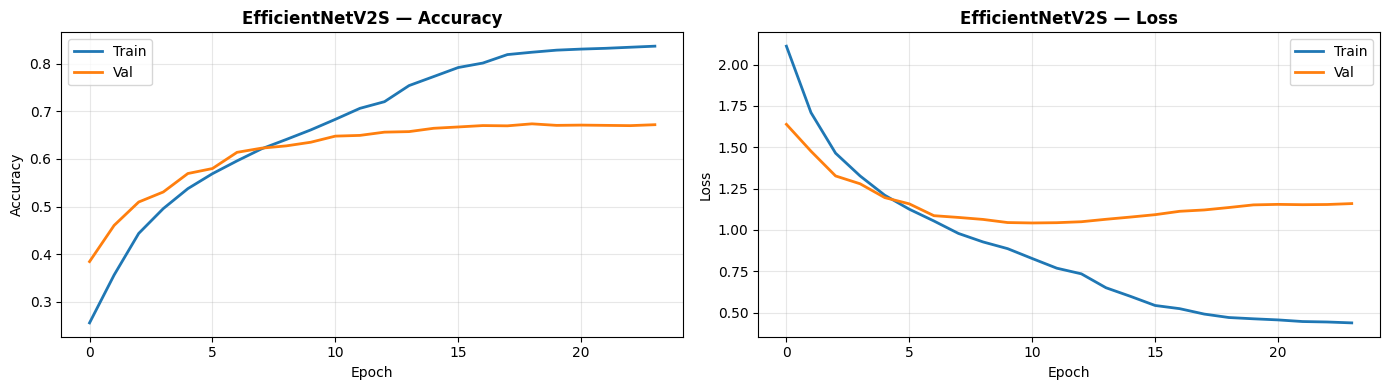

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, ylabel in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(history.history[metric],          label='Train', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2)
    ax.set_title(f'EfficientNetV2S — {ylabel}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
class_names = sorted(os.listdir(train_dir))
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

all_preds, all_labels = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Test Loss:     1.1355
Test Accuracy: 0.6734
              precision    recall  f1-score   support

       angry     0.5824    0.6013    0.5917       958
     disgust     0.7064    0.6937    0.7000       111
        fear     0.5714    0.5195    0.5442      1024
       happy     0.8737    0.8343    0.8535      1774
     neutral     0.5964    0.6521    0.6230      1233
         sad     0.5472    0.5437    0.5455      1247
    surprise     0.7915    0.8267    0.8087       831

    accuracy                         0.6734      7178
   macro avg     0.6670    0.6673    0.6667      7178
weighted avg     0.6752    0.6734    0.6738      7178



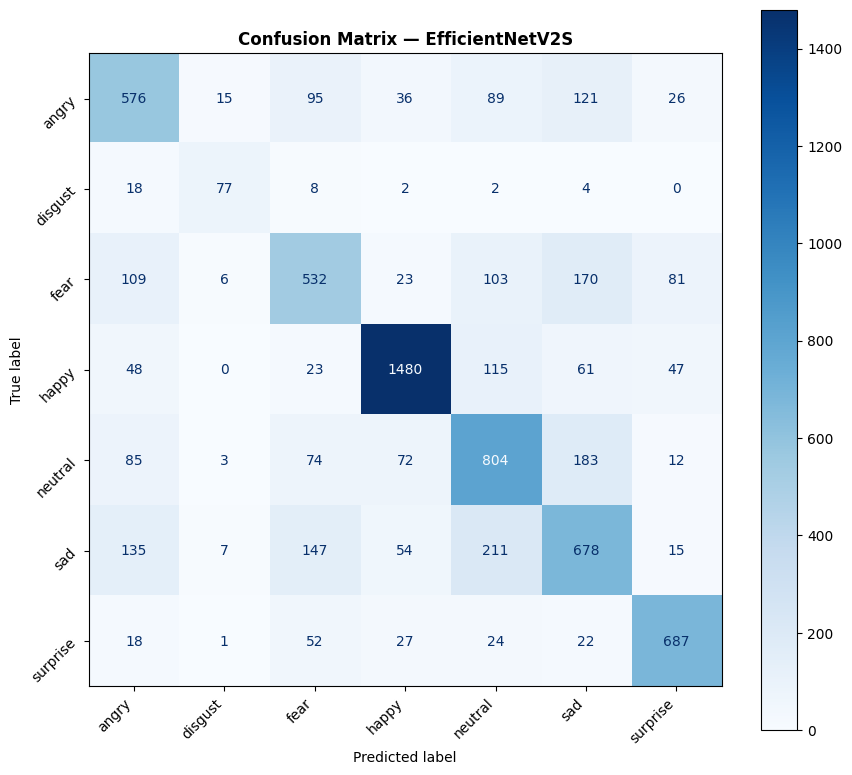

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — EfficientNetV2S', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()